# PR–BTW headway analysis: pooled and flow-regime distributions

This notebook-style script performs the requested workflow continuously:

1. loads `D:\Headway\data3.xlsx`;
2. creates `D:\Headway\final run\tables` and
   `D:\Headway\final run\figures`;
3. exports the inferential-statistics table;
4. fits nine candidate distributions to pooled PR and BTW headways;
5. fits the same distributions within Low, Moderate, and High flow regimes;
6. uses 1,000-replicate refitted parametric bootstraps for KS and AD p-values;
7. exports all fits and the models within ΔAICc ≤ 2; and
8. saves two clean 2×2 collage figures (one for PR and one for BTW).

The script can be run from Jupyter cell-by-cell or as a complete Python file.



In [1]:
from __future__ import annotations

import hashlib
import math
import os
import time
import warnings
from pathlib import Path
from typing import Any

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from joblib import Parallel, delayed
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator
from openpyxl import load_workbook
from openpyxl.styles import Alignment, Border, Font, PatternFill, Side
from scipy import stats

warnings.filterwarnings("ignore", category=RuntimeWarning)

# ------------------------------ paths ---------------------------------------
# Default path requested for the study. The environment-variable override is
# only a convenience for testing or moving the project to another computer.
BASE_DIR = Path(os.environ.get("HEADWAY_BASE_DIR", r"D:\Headway"))
DATA_FILE = BASE_DIR / "data3.xlsx"
FINAL_RUN_DIR = BASE_DIR / "final run"
TABLES_DIR = FINAL_RUN_DIR / "tables"
FIGURES_DIR = FINAL_RUN_DIR / "figures"

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------- analysis settings ----------------------------
MASTER_SEED = 20260729
N_BOOT = int(os.environ.get("HEADWAY_N_BOOT", "1000"))
N_JOBS = int(
    os.environ.get(
        "HEADWAY_N_JOBS",
        str(max(1, min(4, os.cpu_count() or 1))),
    )
)
DELTA_AICC_KEEP = 2.0
ALPHA = 0.05

TH = "Time_Headway"
FLOW = "Flow_pcu/hr/m"
TARGET = "V_Target"
REGIME = "Flow_regime"
REGIME_LABELS = ["Low", "Moderate", "High"]

print(f"Data file : {DATA_FILE}")
print(f"Tables    : {TABLES_DIR}")
print(f"Figures   : {FIGURES_DIR}")
print(f"Bootstrap : {N_BOOT:,} successful replicates per stratum–distribution fit")
print(f"Workers   : {N_JOBS}")



Data file : D:\Headway\data3.xlsx
Tables    : D:\Headway\final run\tables
Figures   : D:\Headway\final run\figures
Bootstrap : 1,000 successful replicates per stratum–distribution fit
Workers   : 4


## 1. Load, validate, and prepare the canonical dataset



In [2]:
REQUIRED_COLUMNS = [
    "V_Target",
    "V_Leading_Class",
    "Pair",
    "Time_Headway",
    "Target_Speed_km/hr",
    "Leading_Speed_km/hr",
    "Speed_Difference",
    "Off_centeredness",
    "Occupancy",
    "Flow_pcu/hr/m",
    "Site",
]


def coerce_binary(series: pd.Series, name: str) -> pd.Series:
    """Convert common Boolean encodings to True/False without silent guessing."""
    if pd.api.types.is_bool_dtype(series):
        return series.astype(bool)

    mapping = {
        True: True,
        False: False,
        1: True,
        0: False,
        "1": True,
        "0": False,
        "true": True,
        "false": False,
        "yes": True,
        "no": False,
        "y": True,
        "n": False,
        "occupied": True,
        "unoccupied": False,
        "off-centered": True,
        "off centered": True,
        "centered": False,
    }
    normalized = series.map(
        lambda value: value.strip().lower() if isinstance(value, str) else value
    )
    converted = normalized.map(mapping)
    if converted.isna().any():
        bad = sorted(normalized[converted.isna()].astype(str).unique())
        raise ValueError(f"Unrecognized values in {name}: {bad}")
    return converted.astype(bool)


if not DATA_FILE.exists():
    raise FileNotFoundError(
        f"Data file not found: {DATA_FILE}\n"
        "Place data3.xlsx in D:\\Headway or change BASE_DIR in the first cell."
    )

raw_df = pd.read_excel(DATA_FILE, sheet_name=0)
raw_df.columns = [str(column).strip() for column in raw_df.columns]

missing_columns = sorted(set(REQUIRED_COLUMNS) - set(raw_df.columns))
if missing_columns:
    raise KeyError(f"Required columns are missing: {missing_columns}")

df = raw_df[REQUIRED_COLUMNS].copy()

numeric_columns = [
    "Time_Headway",
    "Target_Speed_km/hr",
    "Leading_Speed_km/hr",
    "Speed_Difference",
    "Flow_pcu/hr/m",
]
for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

df["Off_centeredness"] = coerce_binary(df["Off_centeredness"], "Off_centeredness")
df["Occupancy"] = coerce_binary(df["Occupancy"], "Occupancy")
df[TARGET] = df[TARGET].astype(str).str.strip().str.upper()
df["V_Leading_Class"] = df["V_Leading_Class"].astype(str).str.strip()
df["Pair"] = df["Pair"].astype(str).str.strip()
df["Site"] = df["Site"].astype(str).str.strip()

valid = (
    df[numeric_columns].notna().all(axis=1)
    & np.isfinite(df[numeric_columns]).all(axis=1)
    & (df[TH] > 0)
)
excluded_rows = int((~valid).sum())
df = df.loc[valid].copy().reset_index(drop=True)

unexpected_targets = sorted(set(df[TARGET]) - {"PR", "BTW"})
if unexpected_targets:
    raise ValueError(f"Unexpected target classes: {unexpected_targets}")

# Pooled tertiles are used for both PR and BTW, so regime cut-points are directly
# comparable between target classes.
q_low, q_high = df[FLOW].quantile([1 / 3, 2 / 3]).to_numpy()
df[REGIME] = pd.Categorical(
    pd.cut(
        df[FLOW],
        bins=[-np.inf, q_low, q_high, np.inf],
        labels=REGIME_LABELS,
        include_lowest=True,
        right=True,
    ),
    categories=REGIME_LABELS,
    ordered=True,
)

if df[REGIME].isna().any():
    raise RuntimeError("At least one valid record could not be assigned to a flow regime.")

data_audit = pd.DataFrame(
    {
        "Item": [
            "Rows in source file",
            "Rows excluded by numeric/positive validity checks",
            "Rows retained",
            "PR observations",
            "BTW observations",
            "Low/Moderate cut-point (PCU/h/m)",
            "Moderate/High cut-point (PCU/h/m)",
        ],
        "Value": [
            len(raw_df),
            excluded_rows,
            len(df),
            int((df[TARGET] == "PR").sum()),
            int((df[TARGET] == "BTW").sum()),
            q_low,
            q_high,
        ],
    }
)

regime_definition = pd.DataFrame(
    [
        {
            "Regime": regime,
            "Lower bound (PCU/h/m)": (
                float(df[FLOW].min()) if regime == "Low" else q_low if regime == "Moderate" else q_high
            ),
            "Upper bound (PCU/h/m)": (
                q_low if regime == "Low" else q_high if regime == "Moderate" else float(df[FLOW].max())
            ),
            "Mean flow (PCU/h/m)": float(df.loc[df[REGIME] == regime, FLOW].mean()),
            "n": int((df[REGIME] == regime).sum()),
            "n_PR": int(((df[REGIME] == regime) & (df[TARGET] == "PR")).sum()),
            "n_BTW": int(((df[REGIME] == regime) & (df[TARGET] == "BTW")).sum()),
        }
        for regime in REGIME_LABELS
    ]
)

print(f"\nRetained {len(df):,} observations; excluded {excluded_rows:,}.")
print(
    "Pooled flow-tertile cut-points: "
    f"{q_low:.4f} and {q_high:.4f} PCU/h/m"
)
display(regime_definition.round(4)) if "display" in globals() else print(
    regime_definition.round(4).to_string(index=False)
)




Retained 898 observations; excluded 0.
Pooled flow-tertile cut-points: 438.6028 and 550.0000 PCU/h/m
  Regime  Lower bound (PCU/h/m)  Upper bound (PCU/h/m)  Mean flow (PCU/h/m)   n  n_PR  n_BTW
     Low               197.3684               438.6028             363.2815 300    77    223
Moderate               438.6028               550.0000             494.0913 298    73    225
    High               550.0000               922.2222             618.5877 300    79    221


## 2. Inferential statistics

Non-parametric tests are used consistently:

- Spearman's \(\rho\) for continuous predictors;
- Mann–Whitney U with Cliff's \(\delta\) for binary predictors; and
- Kruskal–Wallis with \(\epsilon^2\) for categorical predictors.

Within-target effect sizes are exported in addition to the requested
`p_BTW` and `p_PR` columns so those p-values remain interpretable.



In [3]:
INFERENCE_SPECS: list[dict[str, Any]] = [
    {
        "variable": "V_Target",
        "scale": "Binary",
        "kind": "binary",
        "levels": ("PR", "BTW"),
        "contrast": "PR vs BTW; positive δ means PR has longer headway",
    },
    {
        "variable": "V_Leading_Class",
        "scale": "Categorical",
        "kind": "categorical",
        "contrast": "Across all observed leader classes",
    },
    {
        "variable": "Pair",
        "scale": "Categorical",
        "kind": "categorical",
        "contrast": "Across all observed target–leader pairs",
        "skip_within": True,
    },
    {
        "variable": "Target_Speed_km/hr",
        "scale": "Continuous",
        "kind": "continuous",
        "contrast": "Monotonic association with time headway",
    },
    {
        "variable": "Leading_Speed_km/hr",
        "scale": "Continuous",
        "kind": "continuous",
        "contrast": "Monotonic association with time headway",
    },
    {
        "variable": "Speed_Difference",
        "scale": "Continuous",
        "kind": "continuous",
        "contrast": "Target speed minus leader speed",
    },
    {
        "variable": "Occupancy",
        "scale": "Binary",
        "kind": "binary",
        "levels": (True, False),
        "contrast": "Occupied vs unoccupied; positive δ means occupied has longer headway",
    },
    {
        "variable": "Off_centeredness",
        "scale": "Binary",
        "kind": "binary",
        "levels": (True, False),
        "contrast": "Off-centered vs centered; positive δ means off-centered has longer headway",
    },
    {
        "variable": "Site",
        "scale": "Binary",
        "kind": "binary",
        "levels": ("Tikatuli", "Shahjahanpur"),
        "contrast": "Tikatuli vs Shahjahanpur; positive δ means Tikatuli has longer headway",
    },
    {
        "variable": "Flow_pcu/hr/m",
        "scale": "Continuous",
        "kind": "continuous",
        "contrast": "Monotonic association with time headway",
    },
]


def holm_adjust(p_values: pd.Series) -> pd.Series:
    """Holm family-wise-error adjustment, retaining missing values."""
    result = pd.Series(np.nan, index=p_values.index, dtype=float)
    valid = p_values.dropna().astype(float)
    if valid.empty:
        return result

    order = valid.sort_values().index
    m = len(order)
    adjusted_sorted: list[float] = []
    running_max = 0.0
    for rank, index in enumerate(order):
        adjusted = min(1.0, (m - rank) * float(valid.loc[index]))
        running_max = max(running_max, adjusted)
        adjusted_sorted.append(running_max)
    result.loc[order] = adjusted_sorted
    return result


def format_p(value: float) -> str:
    if not np.isfinite(value):
        return "—"
    if value < 0.001:
        return "<0.001"
    return f"{value:.4f}"


def signed_effect(metric: str, value: float) -> str:
    if not np.isfinite(value):
        return "—"
    return f"{metric} = {value:+.4f}"


def infer_one(
    subset: pd.DataFrame,
    variable: str,
    kind: str,
    levels: tuple[Any, Any] | None = None,
) -> dict[str, Any]:
    """Test the association between one predictor and time headway."""
    working = subset[[variable, TH]].dropna()
    n = len(working)

    if kind == "continuous":
        if n < 3 or working[variable].nunique() < 2:
            return {"n": n, "statistic": np.nan, "p": np.nan, "effect": np.nan, "metric": "ρ"}
        result = stats.spearmanr(working[variable], working[TH], nan_policy="omit")
        return {
            "n": n,
            "statistic": float(result.statistic),
            "p": float(result.pvalue),
            "effect": float(result.statistic),
            "metric": "ρ",
        }

    if kind == "binary":
        if levels is None:
            observed = list(pd.unique(working[variable]))
            if len(observed) != 2:
                return {"n": n, "statistic": np.nan, "p": np.nan, "effect": np.nan, "metric": "δ"}
            levels = (observed[0], observed[1])
        first = working.loc[working[variable] == levels[0], TH].to_numpy(float)
        second = working.loc[working[variable] == levels[1], TH].to_numpy(float)
        if len(first) == 0 or len(second) == 0:
            return {"n": n, "statistic": np.nan, "p": np.nan, "effect": np.nan, "metric": "δ"}
        result = stats.mannwhitneyu(first, second, alternative="two-sided")
        delta = 2.0 * float(result.statistic) / (len(first) * len(second)) - 1.0
        return {
            "n": n,
            "statistic": float(result.statistic),
            "p": float(result.pvalue),
            "effect": float(delta),
            "metric": "δ",
        }

    groups = [
        group[TH].to_numpy(float)
        for _, group in working.groupby(variable, observed=True)
        if len(group) > 0
    ]
    if len(groups) < 2:
        return {"n": n, "statistic": np.nan, "p": np.nan, "effect": np.nan, "metric": "ε²"}
    result = stats.kruskal(*groups, nan_policy="omit")
    k = len(groups)
    epsilon_squared = max(0.0, (float(result.statistic) - k + 1.0) / (n - k))
    return {
        "n": n,
        "statistic": float(result.statistic),
        "p": float(result.pvalue),
        "effect": float(epsilon_squared),
        "metric": "ε²",
    }


numeric_inference_rows: list[dict[str, Any]] = []
for spec in INFERENCE_SPECS:
    overall = infer_one(df, spec["variable"], spec["kind"], spec.get("levels"))
    within: dict[str, dict[str, Any]] = {}
    for target_class in ["BTW", "PR"]:
        if spec["variable"] == TARGET or spec.get("skip_within", False):
            within[target_class] = {
                "n": int((df[TARGET] == target_class).sum()),
                "statistic": np.nan,
                "p": np.nan,
                "effect": np.nan,
                "metric": overall["metric"],
            }
        else:
            within[target_class] = infer_one(
                df.loc[df[TARGET] == target_class],
                spec["variable"],
                spec["kind"],
                spec.get("levels"),
            )

    test_name = {
        "continuous": "Spearman rank correlation",
        "binary": "Mann–Whitney U",
        "categorical": "Kruskal–Wallis",
    }[spec["kind"]]

    numeric_inference_rows.append(
        {
            "Variable": spec["variable"],
            "Scale": spec["scale"],
            "Test": test_name,
            "Effect metric": overall["metric"],
            "Effect value": overall["effect"],
            "Test statistic": overall["statistic"],
            "p_numeric": overall["p"],
            "n": overall["n"],
            "Effect value_BTW": within["BTW"]["effect"],
            "p_BTW_numeric": within["BTW"]["p"],
            "n_BTW": within["BTW"]["n"],
            "Effect value_PR": within["PR"]["effect"],
            "p_PR_numeric": within["PR"]["p"],
            "n_PR": within["PR"]["n"],
            "Contrast / interpretation": spec["contrast"],
        }
    )

inference_numeric = pd.DataFrame(numeric_inference_rows)
inference_numeric["p_Holm"] = holm_adjust(inference_numeric["p_numeric"])
inference_numeric["p_BTW_Holm"] = holm_adjust(inference_numeric["p_BTW_numeric"])
inference_numeric["p_PR_Holm"] = holm_adjust(inference_numeric["p_PR_numeric"])

inference_table = pd.DataFrame(
    {
        "Variable": inference_numeric["Variable"],
        "Scale": inference_numeric["Scale"],
        "Test": inference_numeric["Test"],
        "Effect Size": [
            signed_effect(metric, value)
            for metric, value in zip(
                inference_numeric["Effect metric"], inference_numeric["Effect value"]
            )
        ],
        "p": inference_numeric["p_numeric"].map(format_p),
        "p_BTW": inference_numeric["p_BTW_numeric"].map(format_p),
        "p_PR": inference_numeric["p_PR_numeric"].map(format_p),
        "Effect Size_BTW": [
            signed_effect(metric, value)
            for metric, value in zip(
                inference_numeric["Effect metric"], inference_numeric["Effect value_BTW"]
            )
        ],
        "Effect Size_PR": [
            signed_effect(metric, value)
            for metric, value in zip(
                inference_numeric["Effect metric"], inference_numeric["Effect value_PR"]
            )
        ],
        "Contrast / interpretation": inference_numeric["Contrast / interpretation"],
    }
)

display(inference_table) if "display" in globals() else print(
    inference_table.to_string(index=False)
)



           Variable       Scale                      Test  Effect Size      p  p_BTW   p_PR Effect Size_BTW Effect Size_PR                                                  Contrast / interpretation
           V_Target      Binary            Mann–Whitney U  δ = +0.4745 <0.001      —      —               —              —                          PR vs BTW; positive δ means PR has longer headway
    V_Leading_Class Categorical            Kruskal–Wallis ε² = +0.0204 <0.001 <0.001 0.5620    ε² = +0.0650   ε² = +0.0000                                         Across all observed leader classes
               Pair Categorical            Kruskal–Wallis ε² = +0.1692 <0.001      —      —               —              —                                    Across all observed target–leader pairs
 Target_Speed_km/hr  Continuous Spearman rank correlation  ρ = -0.3901 <0.001 <0.001 <0.001     ρ = -0.3126    ρ = -0.2505                                    Monotonic association with time headway
Leading_Sp

## 3. Candidate distributions and corrected bootstrap engine

Each bootstrap replicate is generated from the fitted candidate family,
refitted with the same estimation rule, and then evaluated using KS and AD.
Seeds are derived with SHA-256, not Python's randomized `hash()`, so the
results are reproducible between Python sessions and computers.



In [4]:
DISTRIBUTIONS: dict[str, dict[str, Any]] = {
    "gengamma": {
        "label": "Generalized gamma",
        "distribution": stats.gengamma,
        "mode": "floc0",
    },
    "weibull_min": {
        "label": "Weibull",
        "distribution": stats.weibull_min,
        "mode": "floc0",
    },
    "gamma": {"label": "Gamma", "distribution": stats.gamma, "mode": "floc0"},
    "fisk": {
        "label": "Log-logistic",
        "distribution": stats.fisk,
        "mode": "floc0",
    },
    "lognorm": {
        "label": "Log-normal",
        "distribution": stats.lognorm,
        "mode": "floc0",
    },
    "invgauss": {
        "label": "Inverse Gaussian",
        "distribution": stats.invgauss,
        "mode": "floc0",
    },
    "rayleigh": {
        "label": "Rayleigh",
        "distribution": stats.rayleigh,
        "mode": "floc0",
    },
    "expon": {
        "label": "Exponential",
        "distribution": stats.expon,
        "mode": "floc0",
    },
    "pearson3": {
        "label": "Pearson type III",
        "distribution": stats.pearson3,
        "mode": "free",
    },
}
DIST_ORDER = list(DISTRIBUTIONS)


def stable_seed(*parts: Any) -> int:
    payload = "|".join(map(str, (MASTER_SEED, *parts))).encode("utf-8")
    digest = hashlib.sha256(payload).digest()
    return int.from_bytes(digest[:8], "little") % (2**32 - 1)


def fit_parameters(key: str, values: np.ndarray) -> tuple[float, ...]:
    specification = DISTRIBUTIONS[key]
    distribution = specification["distribution"]
    if specification["mode"] == "free":
        parameters = distribution.fit(values)
    else:
        parameters = distribution.fit(values, floc=0.0)
    parameters = tuple(float(value) for value in parameters)
    if not np.all(np.isfinite(parameters)):
        raise FloatingPointError("Non-finite fitted parameter")
    return parameters


def count_free_parameters(key: str, parameters: tuple[float, ...]) -> int:
    # floc=0 is fixed and therefore not counted.
    return len(parameters) if DISTRIBUTIONS[key]["mode"] == "free" else len(parameters) - 1


def gof_statistics(
    distribution: Any,
    values: np.ndarray,
    parameters: tuple[float, ...],
) -> tuple[float, float]:
    """Return fitted-CDF Kolmogorov–Smirnov D and Anderson–Darling A²."""
    ordered = np.sort(np.asarray(values, dtype=float))
    n = len(ordered)
    fitted_cdf = np.clip(
        distribution.cdf(ordered, *parameters),
        1e-12,
        1.0 - 1e-12,
    )
    index = np.arange(1, n + 1, dtype=float)
    ks_d = max(
        np.max(index / n - fitted_cdf),
        np.max(fitted_cdf - (index - 1.0) / n),
    )
    ad_a2 = -n - np.sum(
        (2.0 * index - 1.0)
        * (np.log(fitted_cdf) + np.log(1.0 - fitted_cdf[::-1]))
    ) / n
    return float(ks_d), float(ad_a2)


def bootstrap_gof_pvalues(
    key: str,
    values: np.ndarray,
    fitted_parameters: tuple[float, ...],
    observed_ks: float,
    observed_ad: float,
    n_boot: int,
    seed: int,
) -> tuple[float, float, int, int]:
    """Refitted parametric bootstrap for composite-null KS and AD tests."""
    if n_boot <= 0:
        return np.nan, np.nan, 0, 0

    distribution = DISTRIBUTIONS[key]["distribution"]
    rng = np.random.default_rng(seed)
    exceed_ks = 0
    exceed_ad = 0
    successful = 0
    attempts = 0
    maximum_attempts = max(n_boot * 5, n_boot + 100)

    while successful < n_boot and attempts < maximum_attempts:
        attempts += 1
        try:
            simulated = np.asarray(
                distribution.rvs(
                    *fitted_parameters,
                    size=len(values),
                    random_state=rng,
                ),
                dtype=float,
            )
            if simulated.shape != values.shape or not np.all(np.isfinite(simulated)):
                continue

            bootstrap_parameters = fit_parameters(key, simulated)
            bootstrap_ks, bootstrap_ad = gof_statistics(
                distribution,
                simulated,
                bootstrap_parameters,
            )
            if not np.isfinite(bootstrap_ks) or not np.isfinite(bootstrap_ad):
                continue
        except Exception:
            continue

        successful += 1
        exceed_ks += int(bootstrap_ks >= observed_ks)
        exceed_ad += int(bootstrap_ad >= observed_ad)

    if successful != n_boot:
        raise RuntimeError(
            f"{key}: obtained {successful} successful bootstrap fits "
            f"after {attempts} attempts; {n_boot} were required."
        )

    ks_p = (1.0 + exceed_ks) / (n_boot + 1.0)
    ad_p = (1.0 + exceed_ad) / (n_boot + 1.0)
    return float(ks_p), float(ad_p), successful, attempts


def fit_candidate(
    stratum: str,
    values: np.ndarray,
    key: str,
) -> dict[str, Any]:
    started = time.perf_counter()
    values = np.asarray(values, dtype=float)
    label = DISTRIBUTIONS[key]["label"]
    distribution = DISTRIBUTIONS[key]["distribution"]

    try:
        parameters = fit_parameters(key, values)
        log_likelihood = float(np.sum(distribution.logpdf(values, *parameters)))
        if not np.isfinite(log_likelihood):
            raise FloatingPointError("Non-finite maximized log-likelihood")

        n = len(values)
        k = count_free_parameters(key, parameters)
        aic = 2.0 * k - 2.0 * log_likelihood
        denominator = n - k - 1
        if denominator <= 0:
            raise ValueError("AICc is undefined because n - k - 1 <= 0")
        aicc = aic + 2.0 * k * (k + 1.0) / denominator

        ks_d, ad_a2 = gof_statistics(distribution, values, parameters)
        ks_p, ad_p, bootstrap_successful, bootstrap_attempts = bootstrap_gof_pvalues(
            key=key,
            values=values,
            fitted_parameters=parameters,
            observed_ks=ks_d,
            observed_ad=ad_a2,
            n_boot=N_BOOT,
            seed=stable_seed(stratum, key),
        )

        return {
            "Stratum": stratum,
            "Distribution key": key,
            "Distribution": label,
            "n": n,
            "k": k,
            "Parameters": ", ".join(f"{value:.6g}" for value in parameters),
            "logLik": log_likelihood,
            "AIC": aic,
            "AICc": aicc,
            "KS D": ks_d,
            "KS D (p)": ks_p,
            "AD A²": ad_a2,
            "AD A² (p)": ad_p,
            "Bootstrap successful": bootstrap_successful,
            "Bootstrap attempts": bootstrap_attempts,
            "Fit status": "OK",
            "Error": "",
            "Elapsed seconds": time.perf_counter() - started,
        }
    except Exception as exc:
        return {
            "Stratum": stratum,
            "Distribution key": key,
            "Distribution": label,
            "n": len(values),
            "k": np.nan,
            "Parameters": "",
            "logLik": np.nan,
            "AIC": np.nan,
            "AICc": np.nan,
            "KS D": np.nan,
            "KS D (p)": np.nan,
            "AD A²": np.nan,
            "AD A² (p)": np.nan,
            "Bootstrap successful": 0,
            "Bootstrap attempts": 0,
            "Fit status": "FAILED",
            "Error": str(exc),
            "Elapsed seconds": time.perf_counter() - started,
        }


def fit_strata(strata: dict[str, np.ndarray], stage_name: str) -> pd.DataFrame:
    """Fit all candidates, then calculate within-stratum ΔAICc and weights."""
    tasks = [
        (stratum, np.asarray(values, dtype=float), key)
        for stratum, values in strata.items()
        for key in DIST_ORDER
    ]
    print(
        f"\n{stage_name}: {len(tasks)} candidate fits "
        f"({len(strata)} strata × {len(DIST_ORDER)} distributions)"
    )
    started = time.perf_counter()

    rows = Parallel(n_jobs=N_JOBS, backend="loky", verbose=5)(
        delayed(fit_candidate)(stratum, values, key)
        for stratum, values, key in tasks
    )
    result = pd.DataFrame(rows)

    failed = result["Fit status"] != "OK"
    if failed.any():
        print("\nFailed fits:")
        print(result.loc[failed, ["Stratum", "Distribution", "Error"]].to_string(index=False))

    successful = result.loc[~failed].copy()
    successful["ΔAICc"] = successful.groupby("Stratum")["AICc"].transform(
        lambda series: series - series.min()
    )
    relative_likelihood = np.exp(-0.5 * successful["ΔAICc"])
    successful["wᵢ"] = relative_likelihood / relative_likelihood.groupby(
        successful["Stratum"]
    ).transform("sum")
    successful["Rank"] = (
        successful.groupby("Stratum")["AICc"]
        .rank(method="first")
        .astype(int)
    )
    successful["Within ΔAICc ≤ 2"] = successful["ΔAICc"] <= DELTA_AICC_KEEP + 1e-12
    successful["KS not rejected (0.05)"] = successful["KS D (p)"] >= ALPHA
    successful["AD not rejected (0.05)"] = successful["AD A² (p)"] >= ALPHA

    failed = result.loc[failed].copy()
    for column in [
        "ΔAICc",
        "wᵢ",
        "Rank",
        "Within ΔAICc ≤ 2",
        "KS not rejected (0.05)",
        "AD not rejected (0.05)",
    ]:
        failed[column] = np.nan

    combined = pd.concat([successful, failed], ignore_index=True)
    combined = combined.sort_values(
        ["Stratum", "AICc", "Distribution"],
        na_position="last",
    ).reset_index(drop=True)
    print(f"{stage_name} completed in {(time.perf_counter() - started) / 60:.2f} minutes.")
    return combined



## 4. Pooled PR and BTW distribution fitting



In [5]:
POOLED_STRATA = {
    "PR — Pooled": df.loc[df[TARGET] == "PR", TH].to_numpy(float),
    "BTW — Pooled": df.loc[df[TARGET] == "BTW", TH].to_numpy(float),
}

pooled_fits = fit_strata(POOLED_STRATA, "Pooled fitting")

pooled_best = pooled_fits.loc[
    pooled_fits["Rank"] == 1,
    [
        "Stratum",
        "Distribution",
        "n",
        "AICc",
        "KS D",
        "KS D (p)",
        "AD A²",
        "AD A² (p)",
    ],
]
display(pooled_best) if "display" in globals() else print(
    pooled_best.round(5).to_string(index=False)
)




Pooled fitting: 18 candidate fits (2 strata × 9 distributions)


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:   15.8s
[Parallel(n_jobs=4)]: Done  15 out of  18 | elapsed:   16.2s remaining:    3.2s


Pooled fitting completed in 0.43 minutes.
     Stratum      Distribution   n       AICc    KS D  KS D (p)   AD A²  AD A² (p)
BTW — Pooled             Gamma 669 1663.34983 0.02941   0.20080 0.75771    0.04595
 PR — Pooled Generalized gamma 229  651.56947 0.06186   0.01698 0.65386    0.02697


[Parallel(n_jobs=4)]: Done  18 out of  18 | elapsed:   25.7s finished


## 5. Low, Moderate, and High flow-regime distribution fitting



In [6]:
REGIME_STRATA = {
    f"{target_class} — {regime}": df.loc[
        (df[TARGET] == target_class) & (df[REGIME] == regime),
        TH,
    ].to_numpy(float)
    for target_class in ["PR", "BTW"]
    for regime in REGIME_LABELS
}

empty_strata = [name for name, values in REGIME_STRATA.items() if len(values) == 0]
if empty_strata:
    raise ValueError(f"Empty flow-regime strata: {empty_strata}")

regime_fits = fit_strata(REGIME_STRATA, "Regime-based fitting")

regime_best = regime_fits.loc[
    regime_fits["Rank"] == 1,
    [
        "Stratum",
        "Distribution",
        "n",
        "AICc",
        "KS D",
        "KS D (p)",
        "AD A²",
        "AD A² (p)",
    ],
]
display(regime_best) if "display" in globals() else print(
    regime_best.round(5).to_string(index=False)
)




Regime-based fitting: 54 candidate fits (6 strata × 9 distributions)


[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done  10 tasks      | elapsed:   13.1s


Regime-based fitting completed in 1.27 minutes.
       Stratum      Distribution   n      AICc    KS D  KS D (p)   AD A²  AD A² (p)
    BTW — High             Gamma 221 531.97355 0.06780   0.02198 0.43246    0.31269
     BTW — Low             Gamma 223 567.12636 0.05303   0.15984 0.64318    0.10989
BTW — Moderate  Pearson type III 225 566.28162 0.04858   0.20180 0.49531    0.16184
     PR — High           Weibull  79 220.28094 0.08477   0.15584 0.40154    0.37363
      PR — Low             Gamma  77 226.06122 0.09351   0.10589 0.75533    0.04695
 PR — Moderate Generalized gamma  73 209.14222 0.06907   0.45355 0.34043    0.36563


[Parallel(n_jobs=4)]: Done  54 out of  54 | elapsed:  1.3min finished


## 6. Prepare manuscript tables and export Excel files



In [7]:
all_fits = pd.concat([pooled_fits, regime_fits], ignore_index=True)

stratum_order = [
    "PR — Pooled",
    "PR — Low",
    "PR — Moderate",
    "PR — High",
    "BTW — Pooled",
    "BTW — Low",
    "BTW — Moderate",
    "BTW — High",
]
all_fits["Stratum"] = pd.Categorical(
    all_fits["Stratum"],
    categories=stratum_order,
    ordered=True,
)
all_fits = all_fits.sort_values(["Stratum", "AICc"], na_position="last").reset_index(drop=True)
all_fits["Stratum"] = all_fits["Stratum"].astype(str)

retained_fits = all_fits.loc[
    (all_fits["Fit status"] == "OK") & (all_fits["Within ΔAICc ≤ 2"] == True)
].copy()

requested_columns = [
    "Stratum",
    "Distribution",
    "ΔAICc",
    "wᵢ",
    "KS D",
    "KS D (p)",
    "AD A²",
    "AD A² (p)",
]
additional_columns = [
    "n",
    "k",
    "Rank",
    "logLik",
    "AICc",
    "Parameters",
    "Bootstrap successful",
]
retained_table = retained_fits[requested_columns + additional_columns].copy()


def group_descriptives(values: np.ndarray, stratum: str) -> dict[str, Any]:
    values = np.asarray(values, dtype=float)
    return {
        "Stratum": stratum,
        "n": len(values),
        "Mean": float(np.mean(values)),
        "SD": float(np.std(values, ddof=1)),
        "CV": float(np.std(values, ddof=1) / np.mean(values)),
        "Minimum": float(np.min(values)),
        "Q1": float(np.percentile(values, 25)),
        "Median": float(np.median(values)),
        "Q3": float(np.percentile(values, 75)),
        "Maximum": float(np.max(values)),
        "Skewness": float(stats.skew(values, bias=False)),
        "Excess kurtosis": float(stats.kurtosis(values, fisher=True, bias=False)),
    }


all_strata = {**POOLED_STRATA, **REGIME_STRATA}
descriptives = pd.DataFrame(
    [group_descriptives(all_strata[name], name) for name in stratum_order]
)


def style_excel_workbook(path: Path) -> None:
    """Apply restrained manuscript-table formatting to every worksheet."""
    workbook = load_workbook(path)
    header_fill = PatternFill("solid", fgColor="17365D")
    subheader_fill = PatternFill("solid", fgColor="D9EAF7")
    white_bold = Font(name="Arial", size=10, bold=True, color="FFFFFF")
    body_font = Font(name="Arial", size=10, color="000000")
    thin_gray = Side(style="thin", color="D9E1F2")
    bottom_border = Border(bottom=thin_gray)

    for worksheet in workbook.worksheets:
        worksheet.freeze_panes = "A2"
        worksheet.sheet_view.showGridLines = False
        worksheet.auto_filter.ref = worksheet.dimensions
        worksheet.row_dimensions[1].height = 32

        for cell in worksheet[1]:
            cell.fill = header_fill
            cell.font = white_bold
            cell.alignment = Alignment(
                horizontal="center",
                vertical="center",
                wrap_text=True,
            )

        for row_index in range(2, worksheet.max_row + 1):
            worksheet.row_dimensions[row_index].height = 20
            for cell in worksheet[row_index]:
                cell.font = body_font
                cell.alignment = Alignment(vertical="center")
                cell.border = bottom_border
                if row_index % 2 == 0:
                    cell.fill = PatternFill("solid", fgColor="F7FAFC")

        for column_cells in worksheet.columns:
            letter = column_cells[0].column_letter
            longest = max(
                (len(str(cell.value)) for cell in column_cells if cell.value is not None),
                default=8,
            )
            worksheet.column_dimensions[letter].width = min(max(longest + 2, 11), 42)

        # First-column labels receive a small visual anchor.
        for cell in worksheet["A"][1:]:
            cell.alignment = Alignment(horizontal="left", vertical="center")
        if worksheet.max_row >= 2:
            worksheet["A2"].fill = subheader_fill

    workbook.save(path)


inferential_file = TABLES_DIR / "T1_Inferential_Statistics.xlsx"
with pd.ExcelWriter(inferential_file, engine="openpyxl") as writer:
    inference_table.to_excel(writer, sheet_name="Manuscript_table", index=False)
    inference_numeric.to_excel(writer, sheet_name="Numeric_details", index=False)
    data_audit.to_excel(writer, sheet_name="Data_audit", index=False)
style_excel_workbook(inferential_file)

distribution_file = TABLES_DIR / "T2_Pooled_and_Regime_Distributions.xlsx"
with pd.ExcelWriter(distribution_file, engine="openpyxl") as writer:
    retained_table.to_excel(writer, sheet_name="Retained_dAICc2", index=False)
    all_fits.to_excel(writer, sheet_name="All_candidate_fits", index=False)
    descriptives.to_excel(writer, sheet_name="Descriptives", index=False)
    regime_definition.to_excel(writer, sheet_name="Regime_definition", index=False)
    data_audit.to_excel(writer, sheet_name="Data_audit", index=False)
style_excel_workbook(distribution_file)

print(f"\nWrote: {inferential_file}")
print(f"Wrote: {distribution_file}")
display(retained_table.round(5)) if "display" in globals() else print(
    retained_table.round(5).to_string(index=False)
)




Wrote: D:\Headway\final run\tables\T1_Inferential_Statistics.xlsx
Wrote: D:\Headway\final run\tables\T2_Pooled_and_Regime_Distributions.xlsx
       Stratum      Distribution   ΔAICc      wᵢ    KS D  KS D (p)   AD A²  AD A² (p)   n  k  Rank     logLik       AICc                    Parameters  Bootstrap successful
   PR — Pooled Generalized gamma 0.00000 0.55311 0.06186   0.01698 0.65386    0.02697 229  3   1.0 -322.73140  651.56947 0.538935, 4.79786, 0, 3.85614                  1000
   PR — Pooled           Weibull 0.48994 0.43294 0.06978   0.00699 0.94450    0.01698 229  2   2.0 -324.00316  652.05941           3.17946, 0, 3.20493                  1000
      PR — Low             Gamma 0.00000 0.31012 0.09351   0.10589 0.75533    0.04695  77  2   1.0 -110.94953  226.06122          6.55611, 0, 0.420876                  1000
      PR — Low           Weibull 0.35741 0.25937 0.12506   0.00699 0.90456    0.02198  77  2   2.0 -111.12823  226.41863           2.88185, 0, 3.10434                

## 7. Two clean collage figures: pooled plus three regimes



Wrote: D:\Headway\final run\figures\F1_PR_Pooled_and_Flow_Regimes.png
Wrote: D:\Headway\final run\figures\F1_PR_Pooled_and_Flow_Regimes.pdf


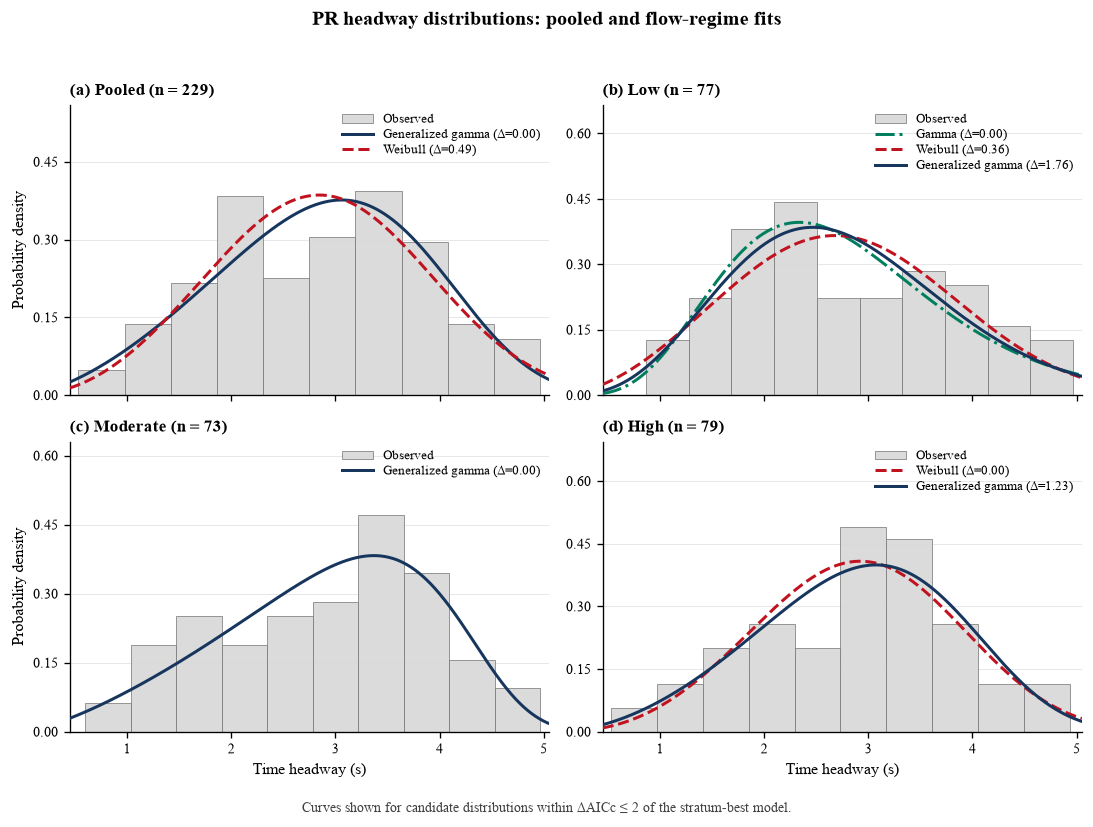

Wrote: D:\Headway\final run\figures\F2_BTW_Pooled_and_Flow_Regimes.png
Wrote: D:\Headway\final run\figures\F2_BTW_Pooled_and_Flow_Regimes.pdf


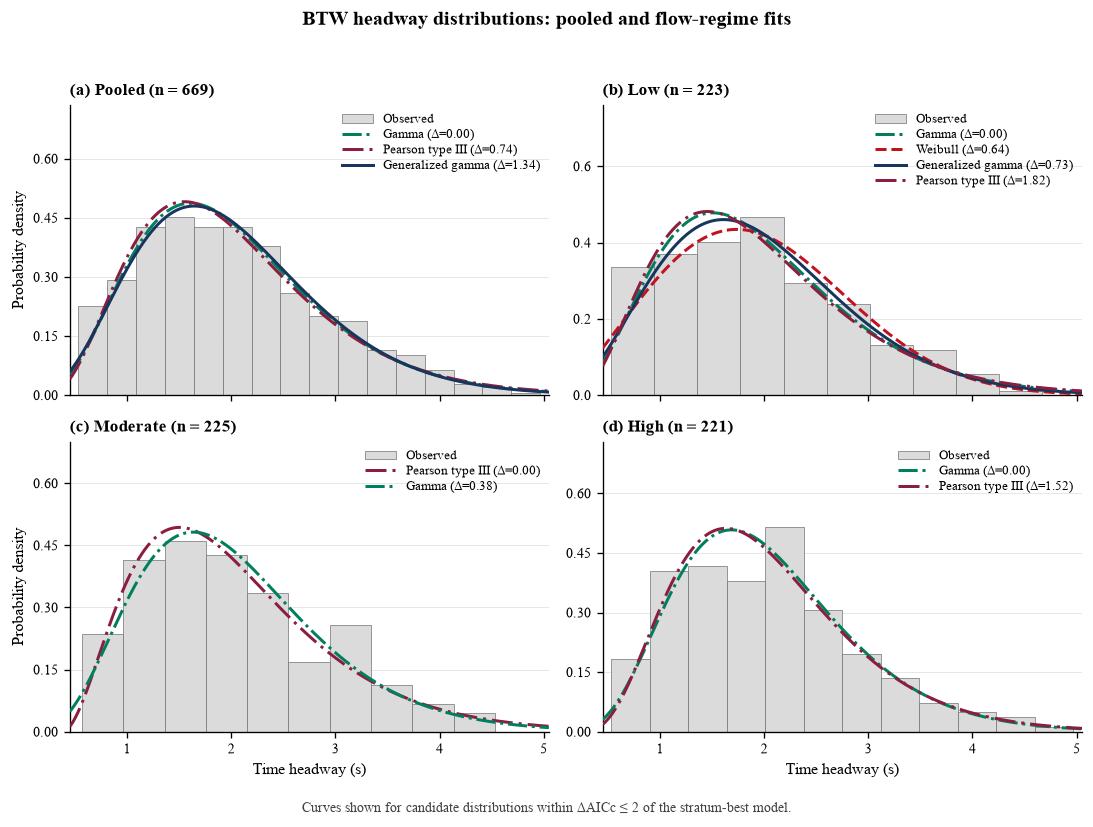

In [8]:
for candidate_font in ["Times New Roman", "Nimbus Roman", "Liberation Serif", "DejaVu Serif"]:
    if any(
        candidate_font.lower() in font.name.lower()
        for font in mpl.font_manager.fontManager.ttflist
    ):
        SERIF_FONT = candidate_font
        break
else:
    SERIF_FONT = "serif"

mpl.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": [SERIF_FONT],
        "font.size": 9.5,
        "axes.titlesize": 10,
        "axes.labelsize": 9.5,
        "xtick.labelsize": 8.5,
        "ytick.labelsize": 8.5,
        "legend.fontsize": 7.5,
        "axes.linewidth": 0.8,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "figure.dpi": 120,
        "savefig.dpi": 600,
        "savefig.bbox": "tight",
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)

DIST_COLORS = {
    "gengamma": "#17365D",
    "weibull_min": "#C1121F",
    "gamma": "#007F5F",
    "fisk": "#E76F51",
    "lognorm": "#6A4C93",
    "invgauss": "#F28E2B",
    "rayleigh": "#577590",
    "expon": "#7F7F7F",
    "pearson3": "#8B1E3F",
}
DIST_LINESTYLES = {
    "gengamma": "-",
    "weibull_min": "--",
    "gamma": "-.",
    "fisk": ":",
    "lognorm": (0, (4, 1, 1, 1)),
    "invgauss": (0, (6, 2)),
    "rayleigh": (0, (1, 1)),
    "expon": (0, (5, 1, 1, 1)),
    "pearson3": (0, (7, 2, 1, 2)),
}


def parse_parameters(parameter_string: str) -> tuple[float, ...]:
    return tuple(float(value.strip()) for value in parameter_string.split(","))


def histogram_bins(values: np.ndarray) -> np.ndarray:
    edges = np.histogram_bin_edges(values, bins="fd")
    number_of_bins = len(edges) - 1
    if number_of_bins < 10:
        return np.linspace(values.min(), values.max(), 11)
    if number_of_bins > 24:
        return np.linspace(values.min(), values.max(), 25)
    return edges


def distribution_panel(
    axis: plt.Axes,
    stratum: str,
    values: np.ndarray,
    panel_label: str,
) -> None:
    values = np.asarray(values, dtype=float)
    bins = histogram_bins(values)
    histogram_height, _ = np.histogram(values, bins=bins, density=True)
    axis.hist(
        values,
        bins=bins,
        density=True,
        color="#D9D9D9",
        edgecolor="#737373",
        linewidth=0.45,
        alpha=0.95,
        label="Observed",
        zorder=1,
    )

    x_grid = np.linspace(
        max(1e-4, min(0.45, values.min() * 0.90)),
        max(5.05, values.max() * 1.02),
        600,
    )
    selected = retained_fits.loc[retained_fits["Stratum"] == stratum].sort_values("AICc")
    maximum_density = float(np.max(histogram_height))

    for _, row in selected.iterrows():
        key = row["Distribution key"]
        distribution = DISTRIBUTIONS[key]["distribution"]
        parameters = parse_parameters(row["Parameters"])
        density = np.asarray(distribution.pdf(x_grid, *parameters), dtype=float)
        finite_density = density[np.isfinite(density)]
        if finite_density.size:
            maximum_density = max(maximum_density, float(finite_density.max()))
        axis.plot(
            x_grid,
            density,
            color=DIST_COLORS[key],
            linestyle=DIST_LINESTYLES[key],
            linewidth=1.8,
            label=f"{row['Distribution']} (Δ={row['ΔAICc']:.2f})",
            zorder=3,
        )

    title_text = stratum.split(" — ", 1)[1]
    axis.set_title(
        f"{panel_label} {title_text} (n = {len(values)})",
        loc="left",
        fontweight="bold",
        pad=6,
    )
    axis.set_xlim(0.45, 5.05)
    axis.set_ylim(0, maximum_density * (1.34 + 0.08 * max(len(selected) - 1, 0)))
    axis.yaxis.set_major_locator(MaxNLocator(5))
    axis.grid(axis="y", color="#E5E5E5", linewidth=0.55)
    axis.set_axisbelow(True)
    axis.legend(
        loc="upper right",
        frameon=False,
        handlelength=2.5,
        borderaxespad=0.3,
        labelspacing=0.28,
    )


def create_collage(target_class: str, figure_number: int) -> None:
    names = [
        f"{target_class} — Pooled",
        f"{target_class} — Low",
        f"{target_class} — Moderate",
        f"{target_class} — High",
    ]
    values_by_name = {
        f"{target_class} — Pooled": POOLED_STRATA[f"{target_class} — Pooled"],
        **{
            f"{target_class} — {regime}": REGIME_STRATA[
                f"{target_class} — {regime}"
            ]
            for regime in REGIME_LABELS
        },
    }

    figure, axes = plt.subplots(
        2,
        2,
        figsize=(9.2, 6.8),
        sharex=True,
        sharey=False,
    )
    for axis, name, panel_label in zip(
        axes.ravel(),
        names,
        ["(a)", "(b)", "(c)", "(d)"],
    ):
        distribution_panel(axis, name, values_by_name[name], panel_label)

    axes[0, 0].set_ylabel("Probability density")
    axes[1, 0].set_ylabel("Probability density")
    axes[1, 0].set_xlabel("Time headway (s)")
    axes[1, 1].set_xlabel("Time headway (s)")
    figure.suptitle(
        f"{target_class} headway distributions: pooled and flow-regime fits",
        fontsize=12,
        fontweight="bold",
        y=0.995,
    )
    figure.text(
        0.5,
        0.01,
        "Curves shown for candidate distributions within ΔAICc ≤ 2 of the stratum-best model.",
        ha="center",
        va="bottom",
        fontsize=8.2,
        color="#404040",
    )
    figure.tight_layout(rect=[0, 0.035, 1, 0.97])

    base_name = f"F{figure_number}_{target_class}_Pooled_and_Flow_Regimes"
    for extension in ["png", "pdf"]:
        output_path = FIGURES_DIR / f"{base_name}.{extension}"
        figure.savefig(output_path, facecolor="white")
        print(f"Wrote: {output_path}")
    plt.show()
    plt.close(figure)


create_collage("PR", figure_number=1)
create_collage("BTW", figure_number=2)



## 8. Final reproducibility checks



In [9]:
expected_strata = set(stratum_order)
observed_strata = set(all_fits["Stratum"])
assert observed_strata == expected_strata, (observed_strata, expected_strata)
assert len(all_fits) == len(expected_strata) * len(DIST_ORDER)
assert retained_table.groupby("Stratum").size().ge(1).all()

successful_bootstraps = all_fits.loc[
    all_fits["Fit status"] == "OK",
    "Bootstrap successful",
]
assert successful_bootstraps.eq(N_BOOT).all()

expected_outputs = [
    inferential_file,
    distribution_file,
    FIGURES_DIR / "F1_PR_Pooled_and_Flow_Regimes.png",
    FIGURES_DIR / "F1_PR_Pooled_and_Flow_Regimes.pdf",
    FIGURES_DIR / "F2_BTW_Pooled_and_Flow_Regimes.png",
    FIGURES_DIR / "F2_BTW_Pooled_and_Flow_Regimes.pdf",
]
missing_outputs = [path for path in expected_outputs if not path.exists()]
if missing_outputs:
    raise FileNotFoundError(f"Expected outputs were not created: {missing_outputs}")

print("\nFINAL RUN COMPLETE")
print(f"Tables  -> {TABLES_DIR}")
print(f"Figures -> {FIGURES_DIR}")



FINAL RUN COMPLETE
Tables  -> D:\Headway\final run\tables
Figures -> D:\Headway\final run\figures


Wrote: D:\Headway\final run\figures\F3_PR_BTW_Pooled_Distributions.png
Wrote: D:\Headway\final run\figures\F3_PR_BTW_Pooled_Distributions.pdf


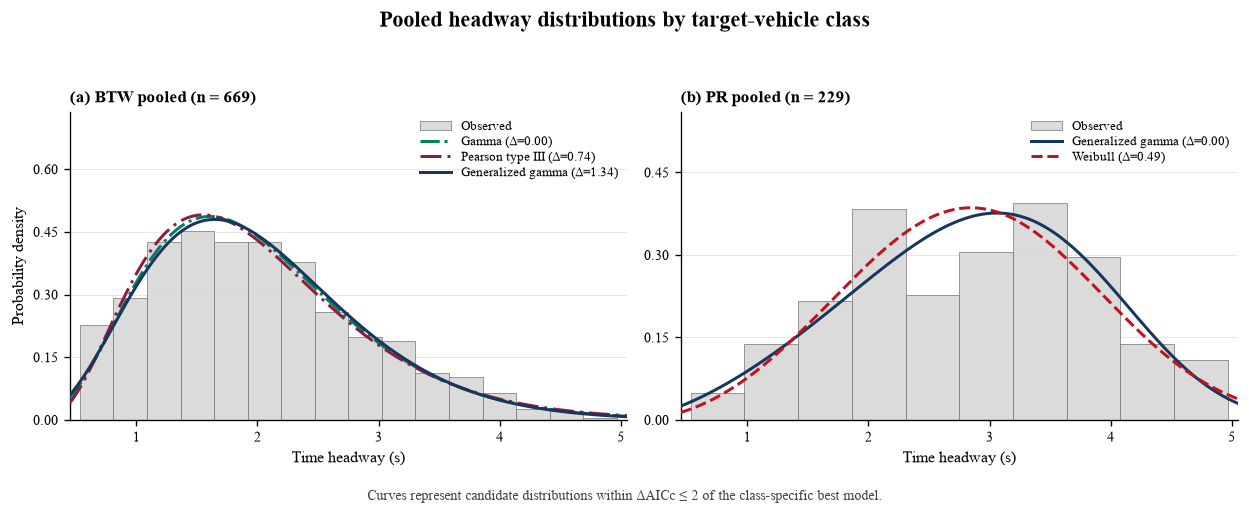

In [10]:
# ============================================================
# Pooled BTW and PR distributions: side-by-side collage
# ============================================================

pooled_panels = [
    ("BTW", "BTW — Pooled", POOLED_STRATA["BTW — Pooled"]),
    ("PR",  "PR — Pooled",  POOLED_STRATA["PR — Pooled"]),
]

figure, axes = plt.subplots(
    1,
    2,
    figsize=(10.5, 4.2),
    sharex=True,
    sharey=False,
)

for axis, (target_class, stratum, values), panel_label in zip(
    axes,
    pooled_panels,
    ["(a)", "(b)"],
):
    # Reuse the plotting function defined in the previous figure cell
    distribution_panel(
        axis=axis,
        stratum=stratum,
        values=values,
        panel_label=panel_label,
    )

    # Replace the generic title with the target-class-specific title
    axis.set_title(
        f"{panel_label} {target_class} pooled (n = {len(values)})",
        loc="left",
        fontweight="bold",
        pad=6,
    )

    axis.set_xlabel("Time headway (s)")

axes[0].set_ylabel("Probability density")
axes[1].set_ylabel("")

figure.suptitle(
    "Pooled headway distributions by target-vehicle class",
    fontsize=13,
    fontweight="bold",
    y=0.99,
)

figure.text(
    0.5,
    0.015,
    "Curves represent candidate distributions within "
    "ΔAICc ≤ 2 of the class-specific best model.",
    ha="center",
    va="bottom",
    fontsize=8.5,
    color="#404040",
)

figure.tight_layout(rect=[0, 0.055, 1, 0.94])

base_name = "F3_PR_BTW_Pooled_Distributions"

for extension in ["png", "pdf"]:
    output_path = FIGURES_DIR / f"{base_name}.{extension}"
    figure.savefig(
        output_path,
        dpi=600,
        bbox_inches="tight",
        facecolor="white",
    )
    print(f"Wrote: {output_path}")

plt.show()
plt.close(figure)

In [11]:
# ============================================================
# PAIRWISE DISTRIBUTION FITTING WITH BOOTSTRAPPED KS AND AD
# Six-family shortlist | Minimum n = 40 | AIC | ΔAIC ≤ 10
# ============================================================

import time
import numpy as np
import pandas as pd
from scipy import stats


# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

MIN_PAIR_N = 40
DELTA_AIC_KEEP = 10.0

ALPHA_GOF = 0.05

# 500 gives p-value resolution of approximately 0.002.
# Increase to 1000 or 2000 for the final manuscript if runtime permits.
N_BOOT_PAIRWISE = 500

BOOTSTRAP_SEED = 20260729
MIN_VALID_BOOT_FRACTION = 0.80


# Six families carried forward from pooled/regime analysis
PAIRWISE_KEYS = [
    "gengamma",
    "gamma",
    "weibull_min",
    "pearson3",
    "lognorm",
    "invgauss",
]

TARGET_ORDER = ["PR", "BTW"]

LEADER_ORDER = [
    "4W",
    "MT_3W",
    "MT_2W",
    "NMT_3W",
    "NMT_2W",
]


# ------------------------------------------------------------
# 1. Family-selection record
# ------------------------------------------------------------

family_decision = pd.DataFrame(
    [
        [
            "Generalized gamma",
            "Yes",
            3,
            "Flexible shape; consistently competitive previously",
        ],
        [
            "Gamma",
            "Yes",
            2,
            "Strong pooled and regime performance",
        ],
        [
            "Weibull",
            "Yes",
            2,
            "Strong PR and regime performance",
        ],
        [
            "Pearson type III",
            "Yes",
            3,
            "Flexible skewness; strong BTW performance",
        ],
        [
            "Log-normal",
            "Yes",
            2,
            "Established positive right-skewed comparator",
        ],
        [
            "Inverse Gaussian",
            "Yes",
            2,
            "Established positive right-skewed comparator",
        ],
        [
            "Log-logistic",
            "No",
            2,
            "Weak previous support and redundant heavy-tailed form",
        ],
        [
            "Rayleigh",
            "No",
            1,
            "Inflexible one-parameter form and weak previous fit",
        ],
        [
            "Exponential",
            "No",
            1,
            "Memoryless form and decisively weak previous fit",
        ],
    ],
    columns=[
        "Distribution",
        "Carried forward",
        "Free parameters",
        "Decision basis",
    ],
)


# ------------------------------------------------------------
# 2. Target–leader pair inventory
# ------------------------------------------------------------

pair_inventory = (
    df.groupby("Pair", observed=True)
    .agg(
        Target=(TARGET, "first"),
        Leader=("V_Leading_Class", "first"),
        n=(TH, "size"),
        mean_headway=(TH, "mean"),
        sd_headway=(TH, "std"),
        skewness=(
            TH,
            lambda series: stats.skew(
                series.to_numpy(dtype=float),
                bias=False,
            ),
        ),
    )
    .reset_index()
)

pair_inventory["Percent of sample"] = (
    100.0 * pair_inventory["n"] / len(df)
)

pair_inventory["Eligible (n ≥ 40)"] = (
    pair_inventory["n"] >= MIN_PAIR_N
)

pair_inventory["Decision"] = np.where(
    pair_inventory["Eligible (n ≥ 40)"],
    "Retained",
    "Excluded: n < 40",
)

pair_inventory["Target"] = pd.Categorical(
    pair_inventory["Target"],
    categories=TARGET_ORDER,
    ordered=True,
)

pair_inventory["Leader"] = pd.Categorical(
    pair_inventory["Leader"],
    categories=LEADER_ORDER,
    ordered=True,
)

pair_inventory = pair_inventory.sort_values(
    ["Target", "Leader"],
    ignore_index=True,
)

eligible_pairs = pair_inventory.loc[
    pair_inventory["Eligible (n ≥ 40)"],
    "Pair",
].tolist()

excluded_pairs = pair_inventory.loc[
    ~pair_inventory["Eligible (n ≥ 40)"],
    ["Pair", "n"],
].copy()


# ------------------------------------------------------------
# 3. Parametric-bootstrap goodness-of-fit test
# ------------------------------------------------------------

def bootstrap_pairwise_gof(
    values,
    key,
    fitted_parameters,
    observed_ks,
    observed_ad,
    n_boot,
    seed,
):
    """
    Lilliefors-type parametric bootstrap for KS D and AD A².

    For every bootstrap replicate:

    1. Generate a sample from the fitted distribution.
    2. Refit the same distribution to the generated sample.
    3. Calculate KS D and AD A² using the refitted parameters.
    4. Compare the bootstrap statistics with the observed statistics.

    This accounts for the fact that the distribution parameters
    were estimated from the same sample being tested.
    """

    values = np.asarray(values, dtype=float)
    n = len(values)

    specification = DISTRIBUTIONS[key]
    distribution = specification["distribution"]

    rng = np.random.default_rng(seed)

    ks_exceedances = 0
    ad_exceedances = 0
    valid_bootstraps = 0

    for _ in range(n_boot):

        try:
            bootstrap_sample = distribution.rvs(
                *fitted_parameters,
                size=n,
                random_state=rng,
            )

            bootstrap_sample = np.asarray(
                bootstrap_sample,
                dtype=float,
            ).reshape(-1)

            # A valid replicate must retain the original sample size.
            if len(bootstrap_sample) != n:
                continue

            if not np.all(np.isfinite(bootstrap_sample)):
                continue

            # Refit the same family to the bootstrap sample.
            bootstrap_parameters = fit_parameters(
                key,
                bootstrap_sample,
            )

            bootstrap_ks, bootstrap_ad = gof_statistics(
                distribution,
                bootstrap_sample,
                bootstrap_parameters,
            )

            if not (
                np.isfinite(bootstrap_ks)
                and np.isfinite(bootstrap_ad)
            ):
                continue

        except Exception:
            continue

        valid_bootstraps += 1

        ks_exceedances += int(
            bootstrap_ks >= observed_ks
        )

        ad_exceedances += int(
            bootstrap_ad >= observed_ad
        )

    minimum_valid = int(
        np.ceil(
            MIN_VALID_BOOT_FRACTION * n_boot
        )
    )

    if valid_bootstraps < minimum_valid:

        return {
            "KS bootstrap p": np.nan,
            "AD bootstrap p": np.nan,
            "Bootstrap valid": valid_bootstraps,
            "Bootstrap requested": n_boot,
            "Bootstrap status": (
                "INSUFFICIENT VALID REPLICATES: "
                f"{valid_bootstraps}/{n_boot}"
            ),
        }

    # Add-one correction prevents a reported p-value of exactly zero.
    ks_p = (
        1.0 + ks_exceedances
    ) / (
        1.0 + valid_bootstraps
    )

    ad_p = (
        1.0 + ad_exceedances
    ) / (
        1.0 + valid_bootstraps
    )

    return {
        "KS bootstrap p": float(ks_p),
        "AD bootstrap p": float(ad_p),
        "Bootstrap valid": valid_bootstraps,
        "Bootstrap requested": n_boot,
        "Bootstrap status": "OK",
    }


# ------------------------------------------------------------
# 4. Fit one distribution to one pair
# ------------------------------------------------------------

def fit_pairwise_candidate(pair, values, key):
    """
    Fit one candidate family by maximum likelihood and calculate
    the observed KS D and AD A² statistics.
    """

    values = np.asarray(values, dtype=float)

    if len(values) == 0:
        raise ValueError("Empty headway sample")

    if not np.all(np.isfinite(values)):
        raise ValueError(
            "Headway sample contains non-finite values"
        )

    if np.any(values <= 0):
        raise ValueError(
            "Headways must be strictly positive"
        )

    specification = DISTRIBUTIONS[key]
    distribution = specification["distribution"]

    parameters = fit_parameters(
        key,
        values,
    )

    log_likelihood = float(
        np.sum(
            distribution.logpdf(
                values,
                *parameters,
            )
        )
    )

    if not np.isfinite(log_likelihood):
        raise FloatingPointError(
            "Non-finite maximized log-likelihood"
        )

    k = count_free_parameters(
        key,
        parameters,
    )

    aic = (
        -2.0 * log_likelihood
        + 2.0 * k
    )

    ks_d, ad_a2 = gof_statistics(
        distribution,
        values,
        parameters,
    )

    return {
        "Pair": pair,
        "Distribution key": key,
        "Distribution": specification["label"],
        "n": len(values),
        "k": k,
        "_Parameter tuple": parameters,
        "Parameters": ", ".join(
            f"{parameter:.6g}"
            for parameter in parameters
        ),
        "logLik": log_likelihood,
        "AIC": aic,
        "KS D": ks_d,
        "AD A²": ad_a2,
        "KS bootstrap p": np.nan,
        "AD bootstrap p": np.nan,
        "Bootstrap valid": 0,
        "Bootstrap requested": 0,
        "Bootstrap status": "Not run",
        "Fit status": "OK",
        "Error": "",
    }


# ------------------------------------------------------------
# 5. Fit six families to every eligible pair
# ------------------------------------------------------------

pairwise_rows = []

for pair_number, pair in enumerate(
    eligible_pairs,
    start=1,
):

    values = df.loc[
        df["Pair"] == pair,
        TH,
    ].to_numpy(dtype=float)

    print(
        f"[Fit {pair_number}/{len(eligible_pairs)}] "
        f"{pair}: n = {len(values)}"
    )

    for key in PAIRWISE_KEYS:

        try:
            result = fit_pairwise_candidate(
                pair=pair,
                values=values,
                key=key,
            )

        except Exception as exc:
            result = {
                "Pair": pair,
                "Distribution key": key,
                "Distribution": DISTRIBUTIONS[key]["label"],
                "n": len(values),
                "k": np.nan,
                "_Parameter tuple": None,
                "Parameters": "",
                "logLik": np.nan,
                "AIC": np.nan,
                "KS D": np.nan,
                "AD A²": np.nan,
                "KS bootstrap p": np.nan,
                "AD bootstrap p": np.nan,
                "Bootstrap valid": 0,
                "Bootstrap requested": 0,
                "Bootstrap status": "Not run",
                "Fit status": "FAILED",
                "Error": str(exc),
            }

        pairwise_rows.append(result)

pairwise_fits = pd.DataFrame(
    pairwise_rows
)


# Attach follower and leader classes
pair_lookup = pair_inventory.set_index(
    "Pair"
)[
    ["Target", "Leader"]
]

pairwise_fits = pairwise_fits.join(
    pair_lookup,
    on="Pair",
)

successful = (
    pairwise_fits["Fit status"] == "OK"
)


# ------------------------------------------------------------
# 6. Calculate ΔAIC, Akaike weights, and ranks
# ------------------------------------------------------------

pairwise_fits.loc[
    successful,
    "ΔAIC",
] = (
    pairwise_fits.loc[
        successful,
        "AIC",
    ]
    - pairwise_fits.loc[
        successful
    ].groupby(
        "Pair"
    )["AIC"].transform(
        "min"
    )
)

pairwise_fits.loc[
    successful,
    "Relative likelihood",
] = np.exp(
    -0.5
    * pairwise_fits.loc[
        successful,
        "ΔAIC",
    ]
)

pairwise_fits.loc[
    successful,
    "wᵢ",
] = (
    pairwise_fits.loc[
        successful,
        "Relative likelihood",
    ]
    / pairwise_fits.loc[
        successful
    ].groupby(
        "Pair"
    )[
        "Relative likelihood"
    ].transform(
        "sum"
    )
)

pairwise_fits.loc[
    successful,
    "Rank",
] = (
    pairwise_fits.loc[
        successful
    ].groupby(
        "Pair"
    )[
        "AIC"
    ].rank(
        method="first"
    )
)

pairwise_fits[
    "Retained (ΔAIC ≤ 10)"
] = (
    successful
    & pairwise_fits[
        "ΔAIC"
    ].le(
        DELTA_AIC_KEEP
    )
)


# ------------------------------------------------------------
# 7. Bootstrap KS and AD for retained models
# ------------------------------------------------------------

bootstrap_indices = pairwise_fits.index[
    pairwise_fits["Retained (ΔAIC ≤ 10)"]
].tolist()

pair_number_lookup = {
    pair: number
    for number, pair in enumerate(
        eligible_pairs,
        start=1,
    )
}

key_number_lookup = {
    key: number
    for number, key in enumerate(
        PAIRWISE_KEYS,
        start=1,
    )
}

bootstrap_start = time.time()

for model_number, row_index in enumerate(
    bootstrap_indices,
    start=1,
):

    row = pairwise_fits.loc[row_index]

    pair = row["Pair"]
    key = row["Distribution key"]

    values = df.loc[
        df["Pair"] == pair,
        TH,
    ].to_numpy(dtype=float)

    model_seed = (
        BOOTSTRAP_SEED
        + 1000 * pair_number_lookup[pair]
        + key_number_lookup[key]
    )

    model_start = time.time()

    print(
        f"[Bootstrap {model_number}/{len(bootstrap_indices)}] "
        f"{pair} | {row['Distribution']}",
        end="",
    )

    bootstrap_result = bootstrap_pairwise_gof(
        values=values,
        key=key,
        fitted_parameters=row["_Parameter tuple"],
        observed_ks=row["KS D"],
        observed_ad=row["AD A²"],
        n_boot=N_BOOT_PAIRWISE,
        seed=model_seed,
    )

    for column, value in bootstrap_result.items():
        pairwise_fits.loc[
            row_index,
            column,
        ] = value

    print(
        f" | valid = "
        f"{bootstrap_result['Bootstrap valid']}"
        f"/{N_BOOT_PAIRWISE}"
        f" | {time.time() - model_start:.1f} s"
    )


# Mark models outside the ΔAIC retention window
not_bootstrapped = (
    successful
    & ~pairwise_fits[
        "Retained (ΔAIC ≤ 10)"
    ]
)

pairwise_fits.loc[
    not_bootstrapped,
    "Bootstrap status",
] = "Not run: ΔAIC > 10"


# ------------------------------------------------------------
# 8. Acceptance decisions
# ------------------------------------------------------------

def acceptance_text(p_value):
    """
    Format the bootstrap p-value and test decision in one
    manuscript-table cell.
    """

    if not np.isfinite(p_value):
        return "Not available"

    decision = (
        "Accepted"
        if p_value >= ALPHA_GOF
        else "Rejected"
    )

    return (
        f"p = {p_value:.3f} "
        f"({decision})"
    )


pairwise_fits[
    "KS D (Acceptance)"
] = pairwise_fits[
    "KS bootstrap p"
].apply(
    acceptance_text
)

pairwise_fits[
    "AD A² (Acceptance)"
] = pairwise_fits[
    "AD bootstrap p"
].apply(
    acceptance_text
)


# Separate machine-readable Boolean decisions
ks_available = pairwise_fits[
    "KS bootstrap p"
].notna()

ad_available = pairwise_fits[
    "AD bootstrap p"
].notna()

pairwise_fits[
    "KS accepted"
] = pd.Series(
    pd.NA,
    index=pairwise_fits.index,
    dtype="boolean",
)

pairwise_fits[
    "AD accepted"
] = pd.Series(
    pd.NA,
    index=pairwise_fits.index,
    dtype="boolean",
)

pairwise_fits.loc[
    ks_available,
    "KS accepted",
] = (
    pairwise_fits.loc[
        ks_available,
        "KS bootstrap p",
    ]
    >= ALPHA_GOF
)

pairwise_fits.loc[
    ad_available,
    "AD accepted",
] = (
    pairwise_fits.loc[
        ad_available,
        "AD bootstrap p",
    ]
    >= ALPHA_GOF
)

pairwise_fits[
    "Accepted by both tests"
] = pd.Series(
    pd.NA,
    index=pairwise_fits.index,
    dtype="boolean",
)

both_available = (
    ks_available
    & ad_available
)

pairwise_fits.loc[
    both_available,
    "Accepted by both tests",
] = (
    pairwise_fits.loc[
        both_available,
        "KS accepted",
    ].astype(bool)
    & pairwise_fits.loc[
        both_available,
        "AD accepted",
    ].astype(bool)
)


# ------------------------------------------------------------
# 9. Apply manuscript ordering
# ------------------------------------------------------------

pairwise_fits["Target"] = pd.Categorical(
    pairwise_fits["Target"],
    categories=TARGET_ORDER,
    ordered=True,
)

pairwise_fits["Leader"] = pd.Categorical(
    pairwise_fits["Leader"],
    categories=LEADER_ORDER,
    ordered=True,
)

pairwise_fits = pairwise_fits.sort_values(
    [
        "Target",
        "Leader",
        "AIC",
        "Distribution",
    ],
    ignore_index=True,
)


# ------------------------------------------------------------
# 10. Retain models within ΔAIC ≤ 10
# ------------------------------------------------------------

retained_pairwise = pairwise_fits.loc[
    pairwise_fits[
        "Retained (ΔAIC ≤ 10)"
    ]
].copy()


# Exact manuscript table requested
manuscript_table = retained_pairwise[
    [
        "Pair",
        "Distribution",
        "ΔAIC",
        "wᵢ",
        "KS D",
        "KS D (Acceptance)",
        "AD A²",
        "AD A² (Acceptance)",
    ]
].copy()

manuscript_table = manuscript_table.rename(
    columns={
        "Pair": "Stratum",
    }
)

manuscript_table["Stratum"] = (
    manuscript_table["Stratum"]
    .str.replace(
        "_following_",
        " → ",
        regex=False,
    )
)


# ------------------------------------------------------------
# 11. Construct pairwise matrices
# ------------------------------------------------------------

pair_order = pair_inventory.loc[
    pair_inventory["Eligible (n ≥ 40)"],
    "Pair",
].tolist()

pair_labels = {
    pair: pair.replace(
        "_following_",
        " → ",
    )
    for pair in pair_order
}

family_order = [
    DISTRIBUTIONS[key]["label"]
    for key in PAIRWISE_KEYS
]


def create_numeric_matrix(value_column):
    """Distribution × pair numeric matrix."""

    matrix = pairwise_fits.pivot(
        index="Distribution",
        columns="Pair",
        values=value_column,
    )

    matrix = matrix.reindex(
        index=family_order,
        columns=pair_order,
    )

    return (
        matrix.rename(
            columns=pair_labels
        )
        .reset_index()
    )


def create_text_matrix(value_column):
    """Distribution × pair text matrix."""

    matrix = pairwise_fits.pivot(
        index="Distribution",
        columns="Pair",
        values=value_column,
    )

    matrix = matrix.reindex(
        index=family_order,
        columns=pair_order,
    )

    return (
        matrix.fillna("—")
        .rename(
            columns=pair_labels
        )
        .reset_index()
    )


delta_aic_matrix = create_numeric_matrix(
    "ΔAIC"
)

akaike_weight_matrix = create_numeric_matrix(
    "wᵢ"
)

ks_d_matrix = create_numeric_matrix(
    "KS D"
)

ks_p_matrix = create_numeric_matrix(
    "KS bootstrap p"
)

ks_acceptance_matrix = create_text_matrix(
    "KS D (Acceptance)"
)

ad_a2_matrix = create_numeric_matrix(
    "AD A²"
)

ad_p_matrix = create_numeric_matrix(
    "AD bootstrap p"
)

ad_acceptance_matrix = create_text_matrix(
    "AD A² (Acceptance)"
)


# Yes/No ΔAIC-retention matrix
retention_matrix = (
    pairwise_fits.assign(
        Cell=np.where(
            pairwise_fits[
                "Retained (ΔAIC ≤ 10)"
            ],
            "Yes",
            "No",
        )
    )
    .pivot(
        index="Distribution",
        columns="Pair",
        values="Cell",
    )
    .reindex(
        index=family_order,
        columns=pair_order,
    )
)

retention_matrix["Retained in"] = (
    retention_matrix.eq("Yes")
    .sum(axis=1)
    .astype(str)
    + f" of {len(pair_order)} pairs"
)

retention_matrix = (
    retention_matrix
    .rename(
        columns=pair_labels
    )
    .reset_index()
)


# Compact support matrix: ΔAIC followed by Akaike weight
support_source = retained_pairwise.copy()

support_source["Cell"] = support_source.apply(
    lambda row: (
        f"{row['ΔAIC']:.2f} "
        f"({row['wᵢ']:.3f})"
    ),
    axis=1,
)

support_matrix = (
    support_source.pivot(
        index="Distribution",
        columns="Pair",
        values="Cell",
    )
    .reindex(
        index=family_order,
        columns=pair_order,
    )
    .fillna("—")
    .rename(
        columns=pair_labels
    )
    .reset_index()
)


# ------------------------------------------------------------
# 12. Methodological record
# ------------------------------------------------------------

method_notes = pd.DataFrame(
    {
        "Item": [
            "Ranking criterion",
            "Retention rule",
            "Minimum pair size",
            "Goodness-of-fit procedure",
            "Bootstrap replicates",
            "Bootstrap refitting",
            "Bootstrap p-value",
            "Acceptance rule",
            "AIC reference",
            "Sample-size reference and limitation",
        ],
        "Specification": [
            "AIC = −2logLik + 2k",
            (
                "Candidate families with ΔAIC ≤ 10 "
                "within each target–leader pair"
            ),
            "n ≥ 40 observations",
            (
                "Parametric-bootstrap Kolmogorov–Smirnov "
                "and Anderson–Darling tests"
            ),
            f"{N_BOOT_PAIRWISE} replicates per retained model",
            (
                "The same distribution family was refitted "
                "within every bootstrap replicate"
            ),
            (
                "p = (1 + number of bootstrap statistics "
                "at least as large as observed)/(B + 1)"
            ),
            (
                f"Accepted when the corresponding bootstrap "
                f"p-value ≥ {ALPHA_GOF:.2f}"
            ),
            (
                "Burnham and Anderson (2004), "
                "doi:10.1177/0049124104268644"
            ),
            (
                "Choi and Wette (1969), "
                "doi:10.1080/00401706.1969.10490731. "
                "The n ≥ 40 cutoff is a conservative study rule, "
                "not a universal guarantee of unbiased estimation."
            ),
        ],
    }
)


# ------------------------------------------------------------
# 13. Prepare export data
# ------------------------------------------------------------

# Remove the internal parameter tuple from Excel output.
pairwise_fits_export = pairwise_fits.drop(
    columns=["_Parameter tuple"],
    errors="ignore",
)

retained_pairwise_export = retained_pairwise.drop(
    columns=["_Parameter tuple"],
    errors="ignore",
)


# ------------------------------------------------------------
# 14. Export tables
# ------------------------------------------------------------

pairwise_output = (
    TABLES_DIR
    / "T3_Pairwise_AIC_Bootstrap_GOF.xlsx"
)

with pd.ExcelWriter(
    pairwise_output,
    engine="openpyxl",
) as writer:

    method_notes.to_excel(
        writer,
        sheet_name="S0_Method",
        index=False,
    )

    family_decision.to_excel(
        writer,
        sheet_name="S1_Family_decision",
        index=False,
    )

    pair_inventory.to_excel(
        writer,
        sheet_name="S2_Pair_inventory",
        index=False,
    )

    pairwise_fits_export.to_excel(
        writer,
        sheet_name="S3_All_pairwise_fits",
        index=False,
    )

    retained_pairwise_export.to_excel(
        writer,
        sheet_name="S4_Retained_dAIC10",
        index=False,
    )

    manuscript_table.to_excel(
        writer,
        sheet_name="S5_Manuscript_table",
        index=False,
    )

    support_matrix.to_excel(
        writer,
        sheet_name="S6_Support_matrix",
        index=False,
    )

    delta_aic_matrix.to_excel(
        writer,
        sheet_name="S7_Delta_AIC_matrix",
        index=False,
    )

    akaike_weight_matrix.to_excel(
        writer,
        sheet_name="S8_Weight_matrix",
        index=False,
    )

    ks_d_matrix.to_excel(
        writer,
        sheet_name="S9_KS_D_matrix",
        index=False,
    )

    ks_p_matrix.to_excel(
        writer,
        sheet_name="S10_KS_p_matrix",
        index=False,
    )

    ks_acceptance_matrix.to_excel(
        writer,
        sheet_name="S11_KS_acceptance",
        index=False,
    )

    ad_a2_matrix.to_excel(
        writer,
        sheet_name="S12_AD_A2_matrix",
        index=False,
    )

    ad_p_matrix.to_excel(
        writer,
        sheet_name="S13_AD_p_matrix",
        index=False,
    )

    ad_acceptance_matrix.to_excel(
        writer,
        sheet_name="S14_AD_acceptance",
        index=False,
    )

    retention_matrix.to_excel(
        writer,
        sheet_name="S15_Retention_matrix",
        index=False,
    )


# Reuse the workbook-formatting function from the earlier cell.
if "style_excel_workbook" in globals():
    style_excel_workbook(
        pairwise_output
    )


# ------------------------------------------------------------
# 15. Display results
# ------------------------------------------------------------

successful_count = int(
    pairwise_fits[
        "Fit status"
    ].eq("OK").sum()
)

accepted_ks_count = int(
    retained_pairwise[
        "KS accepted"
    ].fillna(False).sum()
)

accepted_ad_count = int(
    retained_pairwise[
        "AD accepted"
    ].fillna(False).sum()
)

accepted_both_count = int(
    retained_pairwise[
        "Accepted by both tests"
    ].fillna(False).sum()
)

print(
    f"\nEligible pairs: {len(eligible_pairs)} "
    f"of {len(pair_inventory)}"
)

if len(excluded_pairs):

    print(
        "Excluded pairs: "
        + ", ".join(
            f"{row.Pair} (n={row.n})"
            for row in excluded_pairs.itertuples()
        )
    )

print(
    f"Successful fits: {successful_count} "
    f"of {len(pairwise_fits)}"
)

print(
    f"Fits retained within ΔAIC ≤ 10: "
    f"{len(retained_pairwise)}"
)

print(
    f"Accepted by bootstrap KS: "
    f"{accepted_ks_count}/{len(retained_pairwise)}"
)

print(
    f"Accepted by bootstrap AD: "
    f"{accepted_ad_count}/{len(retained_pairwise)}"
)

print(
    f"Accepted by both tests: "
    f"{accepted_both_count}/{len(retained_pairwise)}"
)

print(
    f"Bootstrap time: "
    f"{time.time() - bootstrap_start:.1f} seconds"
)

print(
    f"Wrote: {pairwise_output}"
)

display(
    manuscript_table.round(
        {
            "ΔAIC": 3,
            "wᵢ": 3,
            "KS D": 3,
            "AD A²": 3,
        }
    )
)

display(
    support_matrix
)

[Fit 1/8] PR_following_4W: n = 43
[Fit 2/8] PR_following_MT_3W: n = 104
[Fit 3/8] PR_following_NMT_3W: n = 49
[Fit 4/8] BTW_following_4W: n = 250
[Fit 5/8] BTW_following_MT_3W: n = 186
[Fit 6/8] BTW_following_MT_2W: n = 73
[Fit 7/8] BTW_following_NMT_3W: n = 119
[Fit 8/8] BTW_following_NMT_2W: n = 41
[Bootstrap 1/41] PR_following_4W | Generalized gamma | valid = 500/500 | 7.3 s
[Bootstrap 2/41] PR_following_4W | Gamma | valid = 500/500 | 0.1 s
[Bootstrap 3/41] PR_following_4W | Weibull | valid = 500/500 | 1.1 s
[Bootstrap 4/41] PR_following_4W | Pearson type III | valid = 500/500 | 5.3 s
[Bootstrap 5/41] PR_following_4W | Log-normal | valid = 500/500 | 0.0 s
[Bootstrap 6/41] PR_following_4W | Inverse Gaussian | valid = 500/500 | 0.1 s
[Bootstrap 7/41] PR_following_MT_3W | Generalized gamma | valid = 500/500 | 6.9 s
[Bootstrap 8/41] PR_following_MT_3W | Gamma | valid = 500/500 | 0.1 s
[Bootstrap 9/41] PR_following_MT_3W | Weibull | valid = 500/500 | 1.1 s
[Bootstrap 10/41] PR_following_

,Stratum,Distribution,ΔAIC,wᵢ,KS D,KS D (Acceptance),AD A²,AD A² (Acceptance)
0,PR → 4W,Weibull,0.000,0.418,0.143,p = 0.032 (Rejected),0.797,p = 0.046 (Rejected)
1,PR → 4W,Generalized gamma,0.011,0.416,0.114,p = 0.184 (Accepted),0.467,p = 0.208 (Accepted)
2,PR → 4W,Pearson type III,2.798,0.103,0.126,p = 0.034 (Rejected),0.618,p = 0.046 (Rejected)
3,PR → 4W,Gamma,4.287,0.049,0.175,p = 0.006 (Rejected),1.141,p = 0.006 (Rejected)
4,PR → 4W,Log-normal,8.183,0.007,0.189,p = 0.004 (Rejected),1.412,p = 0.004 (Rejected)
5,PR → 4W,Inverse Gaussian,8.467,0.006,0.197,p = 0.002 (Rejected),1.500,p = 0.004 (Rejected)
6,PR → MT_3W,Weibull,0.000,0.604,0.076,p = 0.142 (Accepted),0.441,p = 0.307 (Accepted)
7,PR → MT_3W,Generalized gamma,1.425,0.296,0.070,p = 0.146 (Accepted),0.375,p = 0.244 (Accepted)
8,PR → MT_3W,Pearson type III,3.744,0.093,0.072,p = 0.100 (Accepted),0.504,p = 0.114 (Accepted)
9,PR → MT_3W,Gamma,9.082,0.006,0.117,p = 0.006 (Rejected),0.998,p = 0.016 (Rejected)


Pair,Distribution,PR → 4W,PR → MT_3W,PR → NMT_3W,BTW → 4W,BTW → MT_3W,BTW → MT_2W,BTW → NMT_3W,BTW → NMT_2W
0,Generalized gamma,0.01 (0.416),1.43 (0.296),0.52 (0.368),0.00 (0.402),1.33 (0.148),2.62 (0.082),3.04 (0.081),2.13 (0.089)
1,Gamma,4.29 (0.049),9.08 (0.006),5.18 (0.036),1.94 (0.152),0.27 (0.251),0.79 (0.205),1.18 (0.206),0.39 (0.211)
2,Weibull,0.00 (0.418),0.00 (0.604),0.00 (0.476),0.90 (0.256),—,4.33 (0.035),5.07 (0.029),2.71 (0.066)
3,Pearson type III,2.80 (0.103),3.74 (0.093),2.80 (0.117),1.50 (0.190),0.00 (0.288),0.00 (0.305),0.00 (0.371),1.00 (0.156)
4,Log-normal,8.18 (0.007),—,—,—,1.13 (0.164),1.34 (0.156),2.42 (0.111),0.31 (0.221)
5,Inverse Gaussian,8.47 (0.006),—,—,—,1.33 (0.148),0.70 (0.216),1.22 (0.202),0.00 (0.257)
